### Métricas de clasificación


MÉTRICAS POR MODELO:

               Precision  Recall  F1-score   AUC
Carpeta                                         
informesGPT35       0.61    0.58      0.59  0.75
informesDS          0.45    0.40      0.42  0.64
informesGPT4        0.56    0.56      0.56  0.73
informesGPT4o       0.56    0.75      0.63  0.80


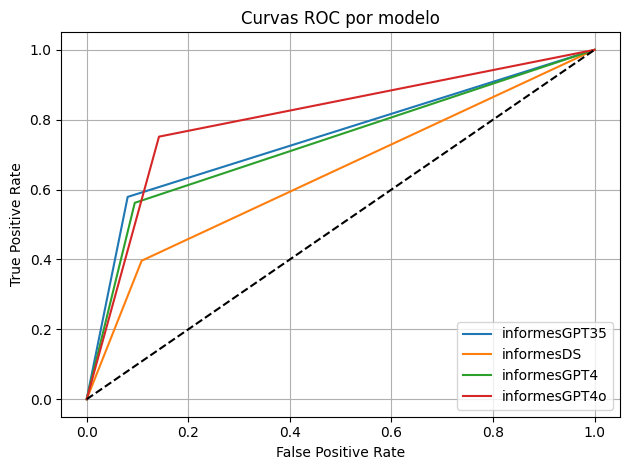

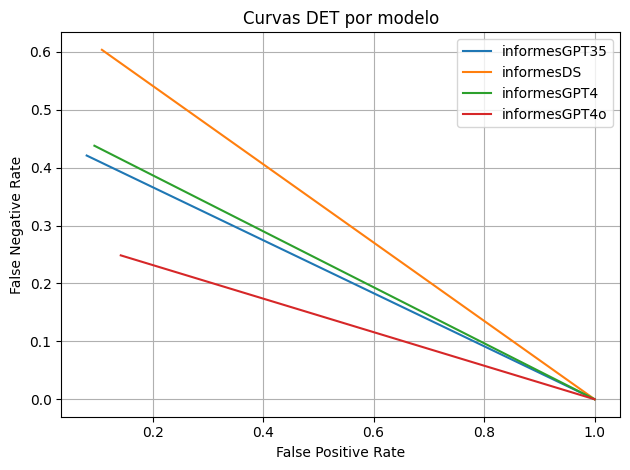

In [1]:
import json
import os
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    det_curve
)
import pandas as pd

def limpiar_json(contratos):
    for contrato, secciones in contratos.items():
        for seccion in secciones:
            if "label_expected" not in seccion and "label_gpt" in seccion:
                del seccion["label_gpt"]
    return contratos

carpetas = ["informesGPT35", "informesDS", "informesGPT4", "informesGPT4o"]  # ajusta según tus carpetas reales
categorias = ["legalidad", "abusividad", "áreas de riesgo", "vaguedades", "lagunas"]

# Guardar métricas y curvas por carpeta
metricas_df = []
curvas_roc = {}
curvas_det = {}

for carpeta in carpetas:
    y_true_total = []
    y_pred_total = []
    metricas = {"Precision": [], "Recall": [], "F1-score": [], "AUC": []}

    if not os.path.isdir(carpeta):
        print(f"Carpeta no encontrada: {carpeta}")
        continue

    for archivo in os.listdir(carpeta):
        if archivo.endswith(".json"):
            with open(os.path.join(carpeta, archivo), "r", encoding="utf-8") as file:
                contratos = json.load(file)

            contratos = limpiar_json(contratos)

            y_true = []
            y_pred = []

            for contrato, secciones in contratos.items():
                for seccion in secciones:
                    label_gpt = seccion.get("label_gpt", {})
                    label_expected = seccion.get("label_expected", {})

                    for categoria in categorias:
                        valor_real = label_expected.get(categoria, "")
                        valor_predicho = label_gpt.get(categoria, "")

                        if categoria == "legalidad":
                            y_true.append(1 if valor_real == "L" else 0)
                            y_pred.append(1 if valor_predicho == "L" else 0)
                        else:
                            y_true.append(1 if valor_real == "S" else 0)
                            y_pred.append(1 if valor_predicho == "S" else 0)

            if y_true and y_pred:
                metricas["Precision"].append(precision_score(y_true, y_pred, zero_division=0))
                metricas["Recall"].append(recall_score(y_true, y_pred, zero_division=0))
                metricas["F1-score"].append(f1_score(y_true, y_pred, zero_division=0))
                metricas["AUC"].append(roc_auc_score(y_true, y_pred))
                y_true_total.extend(y_true)
                y_pred_total.extend(y_pred)

    # Si hay datos en la carpeta
    if y_true_total and y_pred_total:
        avg_metrics = {metrica: sum(valores) / len(valores) if valores else 0 for metrica, valores in metricas.items()}
        avg_metrics["Carpeta"] = carpeta
        metricas_df.append(avg_metrics)

        # Curvas ROC y DET
        fpr, tpr, _ = roc_curve(y_true_total, y_pred_total)
        fpr_det, fnr_det, _ = det_curve(y_true_total, y_pred_total)

        curvas_roc[carpeta] = (fpr, tpr)
        curvas_det[carpeta] = (fpr_det, fnr_det)

# Mostrar tabla de métricas
df = pd.DataFrame(metricas_df)
df.set_index("Carpeta", inplace=True)
print("\nMÉTRICAS POR MODELO:\n")
print(df.round(2))

# Curva ROC
plt.figure()
for carpeta, (fpr, tpr) in curvas_roc.items():
    auc = roc_auc_score(
        [1 if t >= 0.5 else 0 for t in tpr], [1 if f >= 0.5 else 0 for f in fpr]
    )  # solo para mostrar el texto
    plt.plot(fpr, tpr, label=f"{carpeta}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC por modelo")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Curva DET
plt.figure()
for carpeta, (fpr_det, fnr_det) in curvas_det.items():
    plt.plot(fpr_det, fnr_det, label=f"{carpeta}")
plt.xlabel("False Positive Rate")
plt.ylabel("False Negative Rate")
plt.title("Curvas DET por modelo")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Estabilidad, readability, self-consistency, perplexity

In [32]:
import os
import textstat
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import numpy as np
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.corpus import stopwords
import nltk

# Ruta donde están los informes
ruta_informes = "informesGPT35"

# Cargar modelo y tokenizador para calcular perplexity
model_name = "gpt2" 
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)


nltk.download('stopwords')
stopwords_es = stopwords.words('spanish')




def calcular_perplejidad(texto):
    inputs = tokenizer(texto, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs, labels=inputs["input_ids"])
    loss = outputs.loss.item()
    return np.exp(loss)  # e^(loss) da la perplexity

def calcular_coherencia_semantica(textos):
    # Vectorizar los textos usando TF-IDF
    vectorizer = TfidfVectorizer(stop_words=stopwords_es)
    tfidf_matrix = vectorizer.fit_transform(textos)
    
    # Calcular similitud de coseno entre todos los pares de documentos
    similitudes = cosine_similarity(tfidf_matrix)
    
    # Extraer los valores superiores de la diagonal (sin redundancias)
    upper_triangle_indices = np.triu_indices_from(similitudes, k=1)
    coherencia = np.mean(similitudes[upper_triangle_indices])
    
    return coherencia

# Listas para calcular la media
readability_scores = []
perplexity_scores = []
textos = []

for archivo in os.listdir(ruta_informes):
    if archivo.endswith(".txt"):
        with open(os.path.join(ruta_informes, archivo), "r", encoding="utf-8") as file:
            texto = file.read()
            textos.append(texto)

        # Calcular métricas
        readability = textstat.flesch_reading_ease(texto)
        perplexity = calcular_perplejidad(texto)

        # Guardar valores para la media
        readability_scores.append(readability)
        perplexity_scores.append(perplexity)

# Calcular coherencia semántica global
mean_coherence = calcular_coherencia_semantica(textos) if textos else 0

# Calcular medias
mean_readability = np.mean(readability_scores) if readability_scores else 0
mean_perplexity = np.mean(perplexity_scores) if perplexity_scores else 0

# Mostrar resultados globales
print(f"Métrica global - Readability: {mean_readability:.2f}")
print(f"Métrica global - Perplexity: {mean_perplexity:.2f}")
print(f"Métrica global - Semantic Coherence: {mean_coherence:.2f}")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\grill\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Métrica global - Readability: 32.70
Métrica global - Perplexity: 19.39
Métrica global - Semantic Coherence: 0.49


### Readability (Legibilidad)

El índice de legibilidad se basa en la fórmula **Flesch Reading Ease**, que evalúa cuán fácil es leer un texto. La escala es la siguiente:

| **Puntuación** | **Nivel de dificultad**       | **Ejemplo**                    |
|----------------|-------------------------------|--------------------------------|
| 90 - 100       | Muy fácil                     | Nivel de primaria              |
| 60 - 70        | Fácil                         | Nivel de secundaria            |
| 30 - 50        | Difícil                       | Nivel universitario            |
| 0 - 30         | Muy difícil                   | Documentos legales o técnicos  |

---

### Perplexity (Perplejidad)

La perplejidad mide cuán predecible es un texto para un modelo de lenguaje. Cuanto menor sea la perplejidad, más comprensible y fluido resulta el texto. La interpretación es la siguiente:

| **Perplejidad** | **Interpretación**                                                     |
|-----------------|------------------------------------------------------------------------|
| 1 - 10         | Texto muy predecible (frases simples o repetitivas)                    |
| 10 - 50        | Texto natural y bien estructurado                                      |
| 50 - 100       | Texto algo complejo o con errores                                      |
| 100+           | Texto muy confuso o desordenado                                          |

---

### Semantic Coherence (Coherencia Semántica)

La coherencia semántica mide el grado de relación semántica entre diferentes textos utilizando la similitud de coseno entre sus representaciones TF-IDF. Este valor refleja cuán relacionados están los conceptos y las ideas presentadas en los documentos analizados.

| **Puntuación** | **Nivel de Coherencia**       | **Interpretación**                                            |
|------------------|------------------------------|---------------------------------------------------------------|
| 0.0 - 0.3        | Baja                          | Los textos son incoherentes y no presentan temas relacionados. |
| 0.3 - 0.6        | Moderada                      | Hay cierta relación entre los textos, pero no es muy fuerte.  |
| 0.6 - 1.0        | Alta                          | Los textos son altamente coherentes y bien relacionados.       |

---



### Estabilidad y self consistency por clausulas

In [20]:
import os
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import itertools

ruta_informes = "informesGPT4o"

def leer_informes_por_region(ruta):
    regiones = {}
    for archivo in os.listdir(ruta):
        if archivo.endswith(".txt"):  
            partes = archivo.split("_")
            region = "_".join(partes[:-1])  # Extraer el nombre de la región
            with open(os.path.join(ruta, archivo), "r", encoding="utf-8") as f:
                clausulas = f.read().split("###")
                clausulas = [c.strip() for c in clausulas if c.strip()]
                if region not in regiones:
                    regiones[region] = []
                regiones[region].append(clausulas)
    return regiones

def calcular_estabilidad_self_consistency(region, clausulas_por_region):
    num_clausulas = max(len(c) for c in itertools.chain(*clausulas_por_region))
    estabilidad_clausula = []
    consistencia_clausula = []
    
    for i in range(num_clausulas):
        clausulas_actuales = [c[i] for c in clausulas_por_region if len(c) > i]
        if len(clausulas_actuales) < 2:
            continue  # Se necesita al menos 2 versiones para comparar
        
        num_combinaciones = len(clausulas_actuales) * (len(clausulas_actuales) - 1) // 2
        if num_combinaciones < 9:
            continue  # Saltar si no hay al menos 9 combinaciones de comparación

        vectorizer = TfidfVectorizer().fit_transform(clausulas_actuales)
        matriz_similitud = cosine_similarity(vectorizer)
        
        distancias = 1 - matriz_similitud[np.triu_indices(len(clausulas_actuales), k=1)]
        max_dist = np.max(distancias) if len(distancias) > 0 else 1
        estabilidad = 1 - (np.mean(distancias) / max_dist if max_dist > 0 else 0)
        
        contradicciones = sum(1 for d in distancias if d > 0.5)  # Umbral de contradicción
        consistencia = 1 - (contradicciones / len(distancias))

        print(f"[✔] {len(distancias)} distancias válidas")
        estabilidad_clausula.append(estabilidad)
        consistencia_clausula.append(consistencia)
        
        print(f"Región: {region}, Cláusula {i+1}: Estabilidad={estabilidad:.4f}, Self-Consistency={consistencia:.4f}")
    
    return np.mean(estabilidad_clausula), np.mean(consistencia_clausula)


def main():
    regiones = leer_informes_por_region(ruta_informes)
    estabilidad_global, consistencia_global = [], []
    
    for region, clausulas in regiones.items():
        estabilidad, consistencia = calcular_estabilidad_self_consistency(region, clausulas)
        estabilidad_global.append(estabilidad)
        consistencia_global.append(consistencia)
    
    print(f"\nEstabilidad global: {np.mean(estabilidad_global):.4f}")
    print(f"Self-consistency global: {np.mean(consistencia_global):.4f}")

if __name__ == "__main__":
    main()


[✔] 21 distancias válidas
Región: informe_andalucía_1.docx, Cláusula 1: Estabilidad=0.4053, Self-Consistency=0.4286
[✔] 21 distancias válidas
Región: informe_andalucía_1.docx, Cláusula 2: Estabilidad=0.2905, Self-Consistency=0.4286
[✔] 21 distancias válidas
Región: informe_andalucía_1.docx, Cláusula 3: Estabilidad=0.2250, Self-Consistency=0.3810
[✔] 21 distancias válidas
Región: informe_andalucía_1.docx, Cláusula 4: Estabilidad=0.3291, Self-Consistency=0.4762
[✔] 21 distancias válidas
Región: informe_andalucía_1.docx, Cláusula 5: Estabilidad=0.2890, Self-Consistency=0.4762
[✔] 21 distancias válidas
Región: informe_andalucía_1.docx, Cláusula 6: Estabilidad=0.1877, Self-Consistency=0.2381
[✔] 21 distancias válidas
Región: informe_andalucía_1.docx, Cláusula 7: Estabilidad=0.2770, Self-Consistency=0.4286
[✔] 21 distancias válidas
Región: informe_andalucía_1.docx, Cláusula 8: Estabilidad=0.2123, Self-Consistency=0.2857
[✔] 21 distancias válidas
Región: informe_andalucía_1.docx, Clá

### Estabilidad y self consistency por contrato completo

In [24]:
import os
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import itertools

ruta_informes = "informesDS"

def leer_contratos_por_region(ruta):
    regiones = {}
    for archivo in os.listdir(ruta):
        if archivo.endswith(".txt"):  
            partes = archivo.split("_")
            region = "_".join(partes[:-1])  # Extraer el nombre de la región
            with open(os.path.join(ruta, archivo), "r", encoding="utf-8") as f:
                contrato = f.read().strip()
                if region not in regiones:
                    regiones[region] = []
                regiones[region].append(contrato)
    return regiones

def calcular_estabilidad_self_consistency(region, contratos):
    if len(contratos) < 2:
        return 1.0, 1.0  # Si solo hay un contrato, se considera perfecto
    
    vectorizer = TfidfVectorizer().fit_transform(contratos)
    matriz_similitud = cosine_similarity(vectorizer)

    distancias = 1 - matriz_similitud[np.triu_indices(len(contratos), k=1)]
    max_dist = np.max(distancias) if len(distancias) > 0 else 1
    estabilidad = 1 - (np.mean(distancias) / max_dist if max_dist > 0 else 0)
    print(len(distancias))

    contradicciones = sum(1 for d in distancias if d > 0.3)  # Umbral de contradicción
    consistencia = 1 - (contradicciones / len(distancias))

    print(f"Región: {region} - Estabilidad={estabilidad:.4f}, Self-Consistency={consistencia:.4f}")
    return estabilidad, consistencia

def main():
    regiones = leer_contratos_por_region(ruta_informes)
    estabilidad_global, consistencia_global = [], []

    for region, contratos in regiones.items():
        estabilidad, consistencia = calcular_estabilidad_self_consistency(region, contratos)
        estabilidad_global.append(estabilidad)
        consistencia_global.append(consistencia)

    print(f"\nEstabilidad global: {np.mean(estabilidad_global):.4f}")
    print(f"Self-consistency global: {np.mean(consistencia_global):.4f}")

if __name__ == "__main__":
    main()


21
Región: informe_andalucía_1.docx - Estabilidad=0.4129, Self-Consistency=0.3810
21
Región: informe_aragon_1.docx - Estabilidad=0.4727, Self-Consistency=0.5238
21
Región: informe_canarias_1.docx - Estabilidad=0.4492, Self-Consistency=0.5238
21
Región: informe_castilla_y_león.docx - Estabilidad=0.4793, Self-Consistency=0.4762
21
Región: informe_cataluña.docx - Estabilidad=0.3189, Self-Consistency=0.2381
21
Región: informe_extremadura_1.docx - Estabilidad=0.4380, Self-Consistency=0.5238
15
Región: informe_galicia_1.docx - Estabilidad=0.4820, Self-Consistency=0.6000
15
Región: informe_madrid.docx - Estabilidad=0.4670, Self-Consistency=0.5333
15
Región: informe_país_vasco_1.docx - Estabilidad=0.4118, Self-Consistency=0.2667
15
Región: informe_valencia_1.docx - Estabilidad=0.5017, Self-Consistency=0.4000

Estabilidad global: 0.4433
Self-consistency global: 0.4467


#### Métricas de redacción alternativa
#### similaridad métrica a añadir
